In [1]:
# -*- coding: utf-8 -*-
"""
Created on 2023-01-01
Revised on 2026-04-03

@author:       Oscar Trevizo
@institution:  Harvard Extension School — Graduate Data Science Program (2023)
@context:      Independent project — toolbox vignette, R to Python (_r2p)
@environment:  Python 3.14.3 | myenv | MacBook Air M5

Simulate Classification Dataset — Toolbox Vignette (_r2p)
==========================================================

Purpose:
    Shows how to simulate a dataset for binary classification problems.

    In classification:
      - The MEASURING variable is continuous (X)
      - The PREDICTING variable is categorical (Y: A or B)

    Two overlapping Normal distributions with different means simulate
    a realistic classification scenario where the decision boundary
    is not trivially obvious.

    Visualizations:
      1. Histogram of raw X — shows the two-wave bimodal structure
      2. Horizontal boxplot X by class
      3. Stacked histograms — class B (orange) and class A (lightblue)
      4. Scatter X vs Y — shows the classification boundary region

    Note on colors: This vignette uses lightblue/orange (as in original R)
    for the class histograms — a deliberate pedagogical choice separate
    from the Harvard crimson/royalblue palette used in ML notebooks.

    R equivalent: simulate_classification_dataset.Rmd
    R libraries:  base R only (no external packages)
    Python libs:  numpy, pandas, matplotlib, seaborn

    Suffix _r2p: This notebook was converted from R to Python.

    Related toolbox notebooks:
      - prediction_metrics_classification_r2p.ipynb (uses same data structure)
      - simulate_2d_3d_datasets_r2p.ipynb (multivariate extensions)

Revision History:
    2023-01-01  Original R development (Harvard Elements of Statistical Learning, 2021)
                - R script: simulate_classification_dataset.Rmd
                - Based on material by Dr. Sivachenko and Dr. Farutin

    2026-04-03  Converted to Python / Jupyter Notebook (_r2p)
                - c(rnorm(100), rnorm(100, mean=4)) → np.random.default_rng
                - rep(c('A','B'), each=100) → np.array(['A']*100 + ['B']*100)
                - hist() → matplotlib hist
                - boxplot(x~y, horizontal=T) → ax.boxplot(vert=False)
                - Added: scatter X vs Y, class summary statistics
                - Added: simulate_classification() reusable function
"""

"\nCreated on 2023-01-01\nRevised on 2026-04-03\n\n@author:       Oscar Trevizo\n@institution:  Harvard Extension School — Graduate Data Science Program (2023)\n@context:      Independent project — toolbox vignette, R to Python (_r2p)\n@environment:  Python 3.14.3 | myenv | MacBook Air M5\n\nSimulate Classification Dataset — Toolbox Vignette (_r2p)\n==========================================================\n\nPurpose:\n    Shows how to simulate a dataset for binary classification problems.\n\n    In classification:\n      - The MEASURING variable is continuous (X)\n      - The PREDICTING variable is categorical (Y: A or B)\n\n    Two overlapping Normal distributions with different means simulate\n    a realistic classification scenario where the decision boundary\n    is not trivially obvious.\n\n    Visualizations:\n      1. Histogram of raw X — shows the two-wave bimodal structure\n      2. Horizontal boxplot X by class\n      3. Stacked histograms — class B (orange) and class A (li

# Simulate Classification Dataset — Toolbox Vignette

## Purpose

Shows how to simulate a dataset for binary **classification** problems.

> In classification:
> - The **measuring** variable is **continuous** (X)
> - The **predicting** variable is **categorical** (Y: A or B)

Two overlapping Normal distributions with different means create a
realistic scenario where the decision boundary is not trivially obvious.

**R equivalent:** `simulate_classification_dataset.Rmd`

**Related toolbox notebooks:**
- `prediction_metrics_classification_r2p.ipynb` — uses the same data structure
- `simulate_2d_3d_datasets_r2p.ipynb` — multivariate extensions

## Imports

In [2]:
# Standard libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', 20)
sns.set_theme(style='whitegrid')

# -----------------------------------------------------------------------
# Harvard color palette — for reference; lightblue/orange used in plots
# below to match original R vignette colors intentionally
# -----------------------------------------------------------------------
CRIMSON   = '#A51C30'
ROYALBLUE = '#002366'
SLATE     = '#8996A0'
IVY       = '#52854C'

# Class colors — mirrors R: col=c('lightblue','orange')
COLOR_A = 'lightblue'
COLOR_B = 'orange'

print('Imports complete.')

Imports complete.


---

## Reusable Generator Function

Extracted from the simulation code below — a clean, parameterized
function that can be imported into other notebooks.

In [3]:
def simulate_classification(n=100, mu=4, sd=1, seed=11):
    """
    Simulate a binary classification dataset.

    Mirrors R:
        set.seed(11)
        x <- c(rnorm(n), rnorm(n, mean=mu))
        y <- rep(c('A','B'), each=n)
        df <- data.frame(Y=ifelse(y=='A', 0, 1), X=x)

    Two overlapping Normal distributions:
      Class A (Y=0): X ~ N(0, sd)
      Class B (Y=1): X ~ N(mu, sd)

    Parameters
    ----------
    n    : int   — observations per class (total = 2n)
    mu   : float — mean shift for class B (class A always at 0)
    sd   : float — standard deviation for both classes
    seed : int   — random seed (mirrors R set.seed)

    Returns
    -------
    df : pd.DataFrame with columns:
         'X'       — continuous predictor
         'y_label' — categorical label ('A' or 'B')
         'Y'       — numeric label (0=A, 1=B)

    Examples
    --------
    >>> df = simulate_classification(n=100, mu=4, seed=11)
    >>> df.head()
    >>> df['y_label'].value_counts()
    """
    rng = np.random.default_rng(seed=seed)

    # Two Normal distributions — mirrors R: c(rnorm(n), rnorm(n, mean=mu))
    x_A = rng.normal(loc=0,  scale=sd, size=n)   # Class A: N(0, sd)
    x_B = rng.normal(loc=mu, scale=sd, size=n)   # Class B: N(mu, sd)
    x   = np.concatenate([x_A, x_B])

    # Outcome labels — mirrors R: rep(c('A','B'), each=n)
    y_label = np.array(['A'] * n + ['B'] * n)
    Y       = np.where(y_label == 'A', 0, 1)     # numeric: 0=A, 1=B

    return pd.DataFrame({'X': x, 'y_label': y_label, 'Y': Y})


print('simulate_classification() function defined.')

simulate_classification() function defined.


---

## Simulate the Data

Mirrors R:
```r
set.seed(11)
x <- c(rnorm(100), rnorm(100, mean=4))
y <- rep(c('A','B'), each=100)
```

**Parameters:**
- 100 observations per class (200 total)
- Class A: X ~ N(0, 1)
- Class B: X ~ N(4, 1)
- `mu=4` — moderate separation, some overlap near the boundary

In [4]:
# Simulate — mirrors R: set.seed(11); x <- c(rnorm(100), rnorm(100, mean=4))
df = simulate_classification(n=100, mu=4, sd=1, seed=11)

# Convenience aliases — mirrors R variable names
x = df['X'].values
y = df['y_label'].values

print(f'Dataset shape  : {df.shape}  (200 observations, 3 columns)')
print(f'Class balance  : {df["y_label"].value_counts().to_dict()}')
print()
print('Summary statistics by class:')
print(df.groupby('y_label')['X'].describe().round(4))

Dataset shape  : (200, 3)  (200 observations, 3 columns)
Class balance  : {'A': 100, 'B': 100}

Summary statistics by class:
         count    mean     std     min     25%     50%     75%     max
y_label                                                               
A        100.0  0.0247  0.9209 -1.9203 -0.5966  0.0354  0.6441  2.0236
B        100.0  4.0081  0.9331  1.8618  3.3556  4.0112  4.5642  6.5695


In [5]:
df.head(10)

,X,y_label,Y
0,0.034193,A,0
1,1.359748,A,0
2,1.224721,A,0
3,-0.510307,A,0
4,-0.297970,A,0
5,-0.527384,A,0
6,0.569726,A,0
7,-0.056064,A,0
8,0.746886,A,0
9,-1.847325,A,0


---

## Histogram of X

Mirrors R: `hist(x, col='lightgreen', breaks=10)`

The two-wave bimodal structure shows the two underlying distributions.
When we look at X alone, without class labels, we can see the
two Gaussian waves — the signal we want classifiers to exploit.

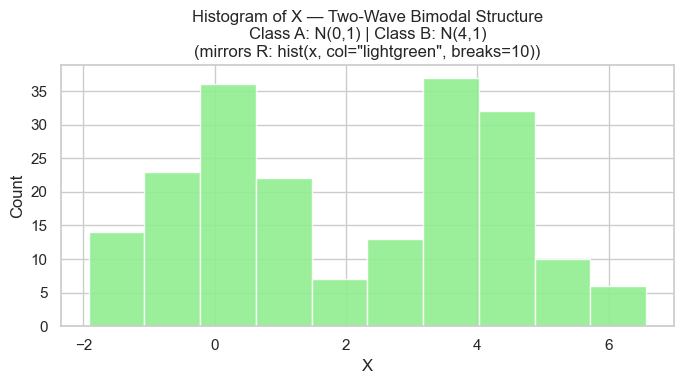

Notice the two overlapping waves — the bimodal structure reveals
the two underlying class distributions.


In [6]:
# Histogram of raw X — mirrors R: hist(x, col='lightgreen', breaks=10)
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(x, bins=10, color='lightgreen', edgecolor='white', alpha=0.9)
ax.set_xlabel('X')
ax.set_ylabel('Count')
ax.set_title('Histogram of X — Two-Wave Bimodal Structure\n'
             'Class A: N(0,1) | Class B: N(4,1)\n'
             '(mirrors R: hist(x, col="lightgreen", breaks=10))')
plt.tight_layout()
plt.show()

print('Notice the two overlapping waves — the bimodal structure reveals')
print('the two underlying class distributions.')

---

## Boxplot and Stacked Histograms

Mirrors R:
```r
boxplot(x~y, col=c('lightblue','orange'), horizontal=T, las=1)
par(mfrow=c(2,1), mar=c(2,2,1,1))
hist(x[y=='B'], breaks=breaks, col='orange', main='B', xaxt='n')
hist(x[y=='A'], breaks=breaks, col='lightblue', main='A')
```

The horizontal boxplot shows the class separation along X.
The stacked histograms reveal the overlap region — the
boundary where misclassification is most likely.

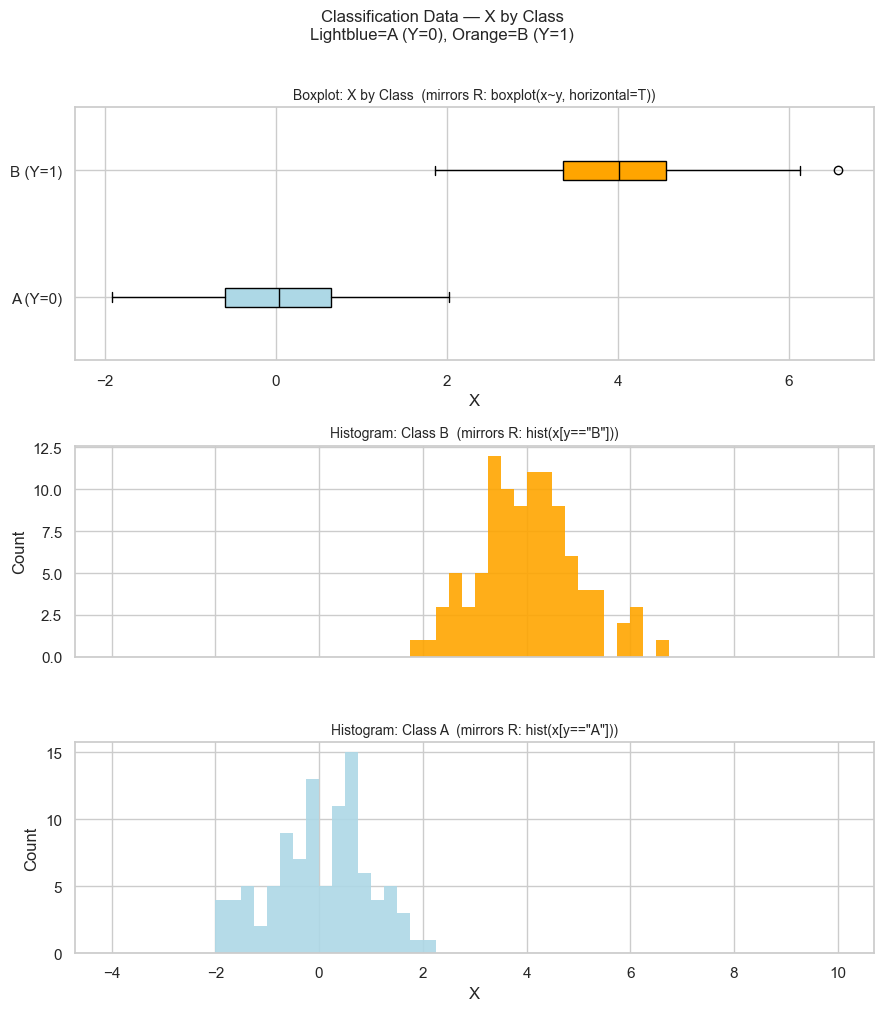

In [7]:
x_A = df['X'][df['y_label'] == 'A'].values
x_B = df['X'][df['y_label'] == 'B'].values
breaks = np.arange(-4, 10.25, 0.25)   # mirrors R: seq(-4, 10, by=0.25)

fig, axes = plt.subplots(3, 1, figsize=(9, 10),
                          gridspec_kw={'height_ratios': [1.2, 1, 1]})

# --- Panel 1: Horizontal boxplot ---
# mirrors R: boxplot(x~y, col=c('lightblue','orange'), horizontal=T, las=1)
bp = axes[0].boxplot([x_A, x_B],
                      vert=False,
                      patch_artist=True,
                      tick_labels=['A (Y=0)', 'B (Y=1)'])
bp['boxes'][0].set_facecolor(COLOR_A)   # lightblue for A
bp['boxes'][1].set_facecolor(COLOR_B)   # orange for B
for element in ['whiskers', 'caps', 'medians', 'fliers']:
    for patch in bp[element]:
        patch.set_color('black')
axes[0].set_title('Boxplot: X by Class  '
                  '(mirrors R: boxplot(x~y, horizontal=T))',
                  fontsize=10)
axes[0].set_xlabel('X')

# --- Panel 2: Histogram for B (orange) ---
# mirrors R: hist(x[y=='B'], breaks=breaks, col='orange', xaxt='n')
axes[1].hist(x_B, bins=breaks, color=COLOR_B, edgecolor='none', alpha=0.9)
axes[1].set_title('Histogram: Class B  (mirrors R: hist(x[y=="B"]))',
                  fontsize=10)
axes[1].set_ylabel('Count')
axes[1].set_xticklabels([])   # mirrors R: xaxt='n'

# --- Panel 3: Histogram for A (lightblue) ---
# mirrors R: hist(x[y=='A'], breaks=breaks, col='lightblue')
axes[2].hist(x_A, bins=breaks, color=COLOR_A, edgecolor='none', alpha=0.9)
axes[2].set_title('Histogram: Class A  (mirrors R: hist(x[y=="A"]))',
                  fontsize=10)
axes[2].set_ylabel('Count')
axes[2].set_xlabel('X')

fig.suptitle('Classification Data — X by Class\n'
             'Lightblue=A (Y=0), Orange=B (Y=1)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Scatter Plot: X vs. Y

Not in the original R script — added here as a useful companion.
Shows each observation as a point: X on the horizontal axis,
class (0 or 1) on the vertical axis. The overlap region
where both classes mix is the decision boundary zone.

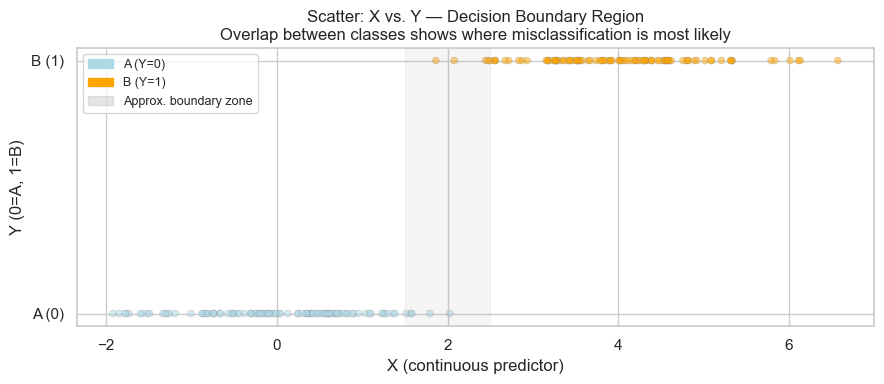

In [8]:
# Scatter X vs Y — shows boundary region clearly
fig, ax = plt.subplots(figsize=(9, 4))

colors_scatter = [COLOR_A if yi == 'A' else COLOR_B for yi in y]
ax.scatter(x, df['Y'].values, c=colors_scatter, alpha=0.5, s=25,
           edgecolors='grey', linewidths=0.3)

ax.set_xlabel('X (continuous predictor)')
ax.set_ylabel('Y (0=A, 1=B)')
ax.set_yticks([0, 1])
ax.set_yticklabels(['A (0)', 'B (1)'])
ax.set_title('Scatter: X vs. Y — Decision Boundary Region\n'
             'Overlap between classes shows where misclassification is most likely')

# Shade the overlap region roughly
ax.axvspan(1.5, 2.5, alpha=0.08, color='grey', label='Approx. boundary zone')
ax.legend(fontsize=9)

patch_A = mpatches.Patch(color=COLOR_A, label='A (Y=0)')
patch_B = mpatches.Patch(color=COLOR_B, label='B (Y=1)')
ax.legend(handles=[patch_A, patch_B,
                   mpatches.Patch(color='grey', alpha=0.2,
                                  label='Approx. boundary zone')],
          fontsize=9)

plt.tight_layout()
plt.show()

---

## Exploring Different Parameters

One advantage of the `simulate_classification()` function:
easy parameter exploration. Vary `mu` and `n` to see how
class separation and sample size affect the data structure.

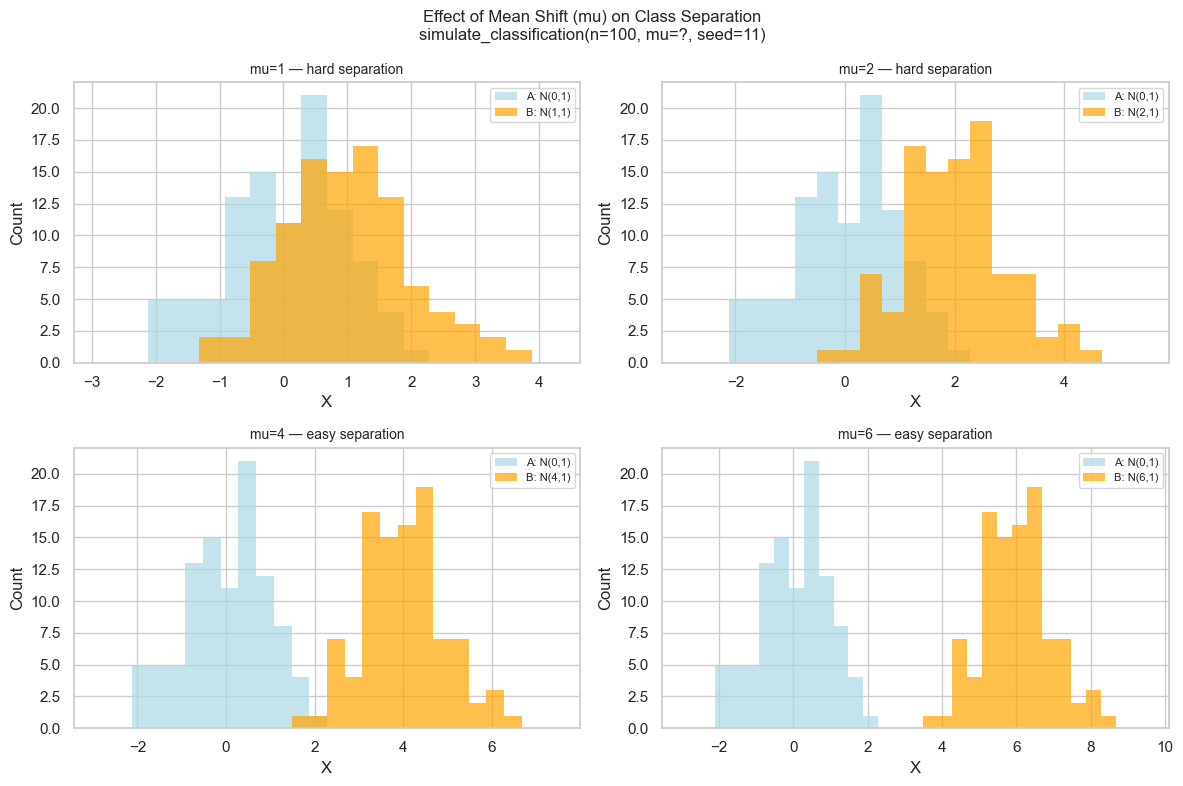

In [9]:
# Compare different mu values — how separation affects overlap
mu_values = [1, 2, 4, 6]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, mu_val in zip(axes, mu_values):
    df_tmp  = simulate_classification(n=100, mu=mu_val, seed=11)
    x_A_tmp = df_tmp['X'][df_tmp['y_label'] == 'A'].values
    x_B_tmp = df_tmp['X'][df_tmp['y_label'] == 'B'].values
    bins    = np.arange(min(df_tmp['X']) - 1,
                         max(df_tmp['X']) + 1, 0.4)

    ax.hist(x_A_tmp, bins=bins, color=COLOR_A, alpha=0.7,
            edgecolor='none', label='A: N(0,1)')
    ax.hist(x_B_tmp, bins=bins, color=COLOR_B, alpha=0.7,
            edgecolor='none', label=f'B: N({mu_val},1)')
    ax.set_title(f'mu={mu_val} — '
                 f'{"easy" if mu_val>=4 else "hard" if mu_val<=2 else "moderate"} separation',
                 fontsize=10)
    ax.set_xlabel('X')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

fig.suptitle('Effect of Mean Shift (mu) on Class Separation\n'
             'simulate_classification(n=100, mu=?, seed=11)',
             fontsize=12)
plt.tight_layout()
plt.show()

---

# Summary

## Key Takeaways

1. **Classification data structure:** A continuous predictor X paired with
   a categorical outcome Y. The X values for each class are drawn from
   Normal distributions with different means — the `mu` parameter
   controls how easy or hard the classification problem is.

2. **mu=4 is the standard** for this toolbox: enough separation to make
   the classes clearly distinguishable, but with meaningful overlap
   in the boundary region around X ≈ 2.

3. **Three visualization layers:**
   - Raw histogram of X alone — reveals bimodal structure
   - Boxplot and stacked histograms by class — shows separation and overlap
   - Scatter X vs Y — shows the decision boundary zone explicitly

4. **`simulate_classification()` function** is the reusable generator —
   parameterized by `n`, `mu`, `sd`, and `seed`. Use it anywhere you
   need a quick binary classification dataset.

## R → Python Mapping

| R | Python |
|---|--------|
| `set.seed(11)` | `np.random.default_rng(seed=11)` |
| `c(rnorm(100), rnorm(100, mean=4))` | `np.concatenate([rng.normal(0,1,100), rng.normal(4,1,100)])` |
| `rep(c('A','B'), each=100)` | `np.array(['A']*100 + ['B']*100)` |
| `hist(x, col='lightgreen', breaks=10)` | `ax.hist(x, bins=10, color='lightgreen')` |
| `boxplot(x~y, col=..., horizontal=T)` | `ax.boxplot([x_A, x_B], vert=False, patch_artist=True)` |
| `tick_labels` (`labels` deprecated mpl 3.9+) | `tick_labels=['A','B']` |
| `x[y=='A']` boolean indexing | `df['X'][df['y_label']=='A'].values` |
| `seq(-4, 10, by=0.25)` | `np.arange(-4, 10.25, 0.25)` |
| `par(mfrow=c(2,1))` | `plt.subplots(3, 1)` |
| `xaxt='n'` (suppress x axis) | `ax.set_xticklabels([])` |

## References

1. Harvard Elements of Statistical Learning (2021),
   Dr. Andrey Sivachenko and Dr. Victor A. Farutin.
2. Gareth James, et al. *An Introduction to Statistical Learning
   with Applications in R*. Springer. ISBN 978-1-4614-7137-0.
3. James, G., Witten, D., Hastie, T., Tibshirani, R., Taylor, J.
   *An Introduction to Statistical Learning with Applications in Python*.
   Springer, 2023. https://www.statlearning.com